In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# 1. Download the latest version of the Yahoo Finance dataset
import kagglehub
path = kagglehub.dataset_download("tanavbajaj/yahoo-finance-all-stocks-dataset-daily-update")
print("Path to dataset files:", path)

# 2. List a few available stock CSVs to verify the path
csv_files = glob.glob(os.path.join(path, "*.csv"))
print(f"Total stock files found: {len(csv_files)}")
print("Sample files:", [os.path.basename(f) for f in csv_files[:5]])

2026-06-15 16:07:06.609866: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781539626.830228      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781539626.898394      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781539627.381602      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781539627.381643      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781539627.381646      58 computation_placer.cc:177] computation placer alr

Path to dataset files: /kaggle/input/datasets/tanavbajaj/yahoo-finance-all-stocks-dataset-daily-update
Total stock files found: 503
Sample files: ['OTIS.csv', 'PNW.csv', 'VTR.csv', 'GOOGL.csv', 'TEL.csv']


In [21]:
# Select a prominent stock file from the dataset path (e.g., AAPL.csv)
# You can change 'AAPL.csv' to 'TSLA.csv' or any other ticker file available in the path.
target_stock = "NVDA.csv"
file_path = os.path.join(path, target_stock)

if not os.path.exists(file_path):
    # Fallback to the first available file if AAPL isn't named exactly
    file_path = csv_files[0]
    print(f"Target stock file not explicitly found. Falling back to: {os.path.basename(file_path)}")

# Load dataset
df = pd.read_csv(file_path)

# Data Preprocessing
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)
df = df.dropna()

print(f"Loaded {os.path.basename(file_path)} with shape: {df.shape}")
print(df.head())

# Filter out the Close price for univariate time-series tracking
data_target = df['Close'].values.reshape(-1, 1)

# Feature Scaling (Crucial for LSTM performance)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data_target)

Loaded NVDA.csv with shape: (6207, 8)
                        Date      Open      High       Low     Close  \
0  1999-01-22 00:00:00-05:00  0.401374  0.447962  0.355981  0.376288   
1  1999-01-25 00:00:00-05:00  0.406152  0.420487  0.376288  0.415709   
2  1999-01-26 00:00:00-05:00  0.420487  0.428849  0.377482  0.383456   
3  1999-01-27 00:00:00-05:00  0.384650  0.394207  0.363147  0.382261   
4  1999-01-28 00:00:00-05:00  0.382261  0.384650  0.378677  0.381067   

      Volume  Dividends  Stock Splits  
0  271468800        0.0           0.0  
1   51048000        0.0           0.0  
2   34320000        0.0           0.0  
3   24436800        0.0           0.0  
4   22752000        0.0           0.0  


/tmp/ipykernel_58/1191093816.py:15: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df['Date'] = pd.to_datetime(df['Date'])


In [22]:
# Lookback window (Using past 60 days of stock data to predict the 61st day)
prediction_days = 60

X = []
y = []

for i in range(prediction_days, len(scaled_data)):
    X.append(scaled_data[i - prediction_days:i, 0])
    y.append(scaled_data[i, 0])

X, y = np.array(X), np.array(y)

# Reshape X to fit the 3D tensor expected by LSTM: [samples, time_steps, features]
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

# Train-Test Split (Chronological split instead of random split to preserve time order)
train_size = int(len(X) * 0.80)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

Training features shape: (4917, 60, 1)
Testing features shape: (1230, 60, 1)


In [23]:
# Initialize Sequential Model
model = Sequential()

# Layer 1: Stacked LSTM layer
model.add(LSTM(units=60, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))

# Layer 2: Second Stacked LSTM layer
model.add(LSTM(units=60, return_sequences=False))
model.add(Dropout(0.2))

# Layer 3: Dense output layer mapping to the next continuous price value
model.add(Dense(units=1))

# Compile using Adam Optimizer and Mean Squared Error Loss function
model.compile(optimizer='adam', loss='mean_squared_error')

# Configure Early Stopping to prevent overfitting if validation loss plateaus
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
print("Starting LSTM training pipeline...")
history = model.fit(
    X_train, y_train, 
    epochs=25, 
    batch_size=32, 
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

Starting LSTM training pipeline...
Epoch 1/25


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


154/154 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 5.7463e-05 - val_loss: 0.0013
Epoch 2/25
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.5800e-05 - val_loss: 0.0014
Epoch 3/25
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.1720e-05 - val_loss: 0.0014
Epoch 4/25
154/154 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1.3209e-05 - val_loss: 7.6754e-04
Epoch 5/25
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.1435e-05 - val_loss: 8.2789e-04
Epoch 6/25
154/154 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1.4152e-05 - val_loss: 0.0036
Epoch 7/25
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.1044e-05 - val_loss: 0.0030
Epoch 8/25
154/154 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1.1513e-05 - val_loss: 0.0016
Epoch 9/25
154/154 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 9.8691e-06 - val_loss: 0.0013


In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Execute Predictions
predictions = model.predict(X_test)

# Inverse scale back to authentic dollar currency valuations
predictions_decoded = scaler.inverse_transform(predictions)
y_test_decoded = scaler.inverse_transform(y_test.reshape(-1, 1))

# Calculate Evaluation Metrics
mae = mean_absolute_error(y_test_decoded, predictions_decoded)
mse = mean_squared_error(y_test_decoded, predictions_decoded)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_decoded, predictions_decoded)

print("\n=== Model Performance Evaluation ===")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score (Variance Explained): {r2:.4f}")

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

=== Model Performance Evaluation ===
Mean Absolute Error (MAE): 8.49
Mean Squared Error (MSE): 186.70
Root Mean Squared Error (RMSE): 13.66
R² Score (Variance Explained): 0.9839


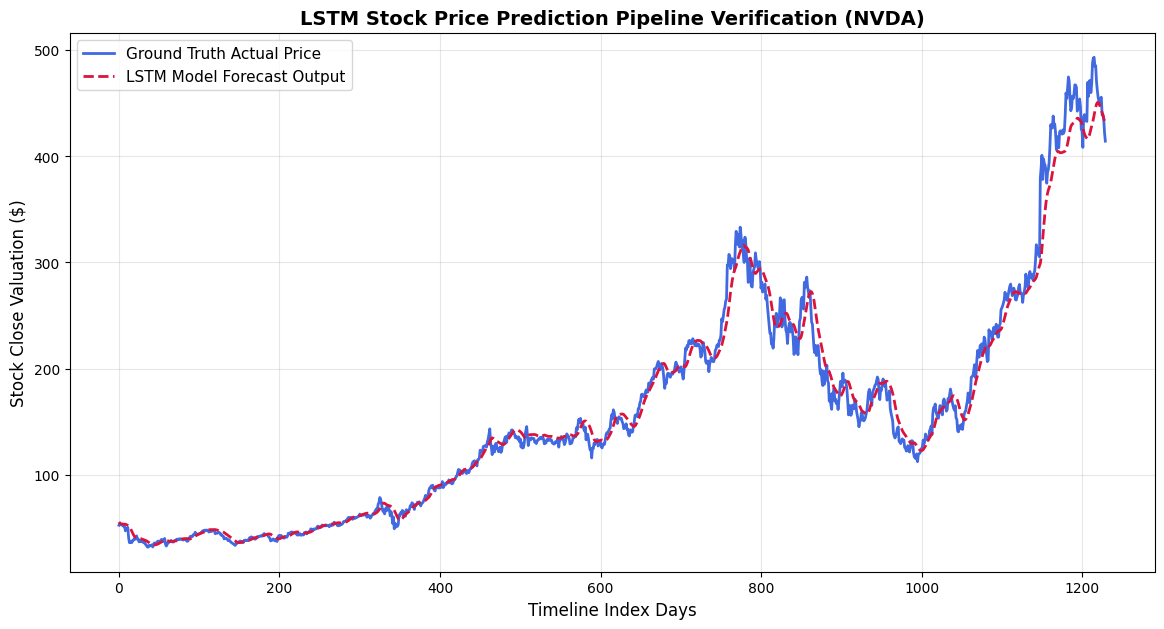

In [26]:
# Create a structured validation DataFrame for charting
train_df_len = train_size + prediction_days
valid_df = df.iloc[train_df_len:].copy().reset_index(drop=True)
valid_df['Predictions'] = predictions_decoded

# Plot Configuration
plt.figure(figsize=(14, 7))
plt.title(f"LSTM Stock Price Prediction Pipeline Verification ({target_stock.replace('.csv', '')})", fontsize=14, fontweight='bold')
plt.xlabel("Timeline Index Days", fontsize=12)
plt.ylabel("Stock Close Valuation ($)", fontsize=12)

# Plot actual vs predicted prices
plt.plot(valid_df['Close'], label='Ground Truth Actual Price', color='royalblue', linewidth=2)
plt.plot(valid_df['Predictions'], label='LSTM Model Forecast Output', color='crimson', linestyle='--', linewidth=2)

plt.grid(True, alpha=0.3)
plt.legend(loc='upper left', fontsize=11)
plt.show()

In [28]:
model.save("lstm_model_nvda.keras")

In [29]:
# 1. Isolate NVIDIA data
nvda_file = os.path.join(path, "NVDA.csv")
df_nvda = pd.read_csv(nvda_file).dropna()
df_nvda['Date'] = pd.to_datetime(df_nvda['Date'])
df_nvda = df_nvda.sort_values('Date').reset_index(drop=True)

# 2. Extract and scale the target close values using your trained scaler
nvda_target = df_nvda['Close'].values.reshape(-1, 1)
nvda_scaled = scaler.transform(nvda_target)

# 3. Extract the final 60-day sequence and reshape for the LSTM
nvda_last_60 = nvda_scaled[-prediction_days:]
nvda_X = np.reshape(nvda_last_60, (1, prediction_days, 1))

# 4. Predict and Inverse Scale
nvda_pred_scaled = model.predict(nvda_X)
nvda_pred = scaler.inverse_transform(nvda_pred_scaled)

# 5. Output results
print("\n================ NVIDIA (NVDA) FUTURE FORECAST ================")
print(f"Last recorded date in dataset: {df_nvda['Date'].max().strftime('%Y-%m-%d')}")
print(f"Last recorded closing price:  ${nvda_target[-1][0]:.2f}")
print(f"➡️ LSTM PREDICTED PRICE FOR THE NEXT TRADING DAY: ${nvda_pred[0][0]:.2f}")
print("===============================================================")

/tmp/ipykernel_58/875152701.py:4: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df_nvda['Date'] = pd.to_datetime(df_nvda['Date'])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

================ NVIDIA (NVDA) FUTURE FORECAST ================
Last recorded date in dataset: 2023-09-21
Last recorded closing price:  $414.38
➡️ LSTM PREDICTED PRICE FOR THE NEXT TRADING DAY: $425.37


In [30]:
# Select a prominent stock file from the dataset path (e.g., AAPL.csv)
# You can change 'AAPL.csv' to 'TSLA.csv' or any other ticker file available in the path.
target_stock = "AAPL.csv"
file_path = os.path.join(path, target_stock)

if not os.path.exists(file_path):
    # Fallback to the first available file if AAPL isn't named exactly
    file_path = csv_files[0]
    print(f"Target stock file not explicitly found. Falling back to: {os.path.basename(file_path)}")

# Load dataset
df = pd.read_csv(file_path)

# Data Preprocessing
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)
df = df.dropna()

print(f"Loaded {os.path.basename(file_path)} with shape: {df.shape}")
print(df.head())

# Filter out the Close price for univariate time-series tracking
data_target = df['Close'].values.reshape(-1, 1)

# Feature Scaling (Crucial for LSTM performance)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data_target)

Loaded AAPL.csv with shape: (10784, 8)
                        Date      Open      High       Low     Close  \
0  1980-12-12 00:00:00-05:00  0.099450  0.099882  0.099450  0.099450   
1  1980-12-15 00:00:00-05:00  0.094694  0.094694  0.094261  0.094261   
2  1980-12-16 00:00:00-05:00  0.087775  0.087775  0.087343  0.087343   
3  1980-12-17 00:00:00-05:00  0.089504  0.089937  0.089504  0.089504   
4  1980-12-18 00:00:00-05:00  0.092099  0.092532  0.092099  0.092099   

      Volume  Dividends  Stock Splits  
0  469033600        0.0           0.0  
1  175884800        0.0           0.0  
2  105728000        0.0           0.0  
3   86441600        0.0           0.0  
4   73449600        0.0           0.0  


/tmp/ipykernel_58/4148500990.py:15: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df['Date'] = pd.to_datetime(df['Date'])


In [31]:
# Lookback window (Using past 60 days of stock data to predict the 61st day)
prediction_days = 60

X = []
y = []

for i in range(prediction_days, len(scaled_data)):
    X.append(scaled_data[i - prediction_days:i, 0])
    y.append(scaled_data[i, 0])

X, y = np.array(X), np.array(y)

# Reshape X to fit the 3D tensor expected by LSTM: [samples, time_steps, features]
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

# Train-Test Split (Chronological split instead of random split to preserve time order)
train_size = int(len(X) * 0.80)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

Training features shape: (8579, 60, 1)
Testing features shape: (2145, 60, 1)


In [32]:
# Initialize Sequential Model
model = Sequential()

# Layer 1: Stacked LSTM layer
model.add(LSTM(units=60, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))

# Layer 2: Second Stacked LSTM layer
model.add(LSTM(units=60, return_sequences=False))
model.add(Dropout(0.2))

# Layer 3: Dense output layer mapping to the next continuous price value
model.add(Dense(units=1))

# Compile using Adam Optimizer and Mean Squared Error Loss function
model.compile(optimizer='adam', loss='mean_squared_error')

# Configure Early Stopping to prevent overfitting if validation loss plateaus
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
print("Starting LSTM training pipeline...")
history = model.fit(
    X_train, y_train, 
    epochs=25, 
    batch_size=32, 
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

Starting LSTM training pipeline...
Epoch 1/25


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


269/269 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 3.1164e-05 - val_loss: 4.6583e-04
Epoch 2/25
269/269 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1.1250e-05 - val_loss: 0.0025
Epoch 3/25
269/269 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 9.9236e-06 - val_loss: 0.0014
Epoch 4/25
269/269 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 9.8625e-06 - val_loss: 9.4152e-04
Epoch 5/25
269/269 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 9.8682e-06 - val_loss: 3.3025e-04
Epoch 6/25
269/269 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 8.6283e-06 - val_loss: 0.0015
Epoch 7/25
269/269 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 8.3017e-06 - val_loss: 0.0013
Epoch 8/25
269/269 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 8.4012e-06 - val_loss: 3.7718e-04
Epoch 9/25
269/269 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 9.6783e-06 - val_loss: 6.5707e-04
Epoch 10/25
269/269 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 8.6519e-06 - val_loss: 8.4912e-04


In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Execute Predictions
predictions = model.predict(X_test)

# Inverse scale back to authentic dollar currency valuations
predictions_decoded = scaler.inverse_transform(predictions)
y_test_decoded = scaler.inverse_transform(y_test.reshape(-1, 1))

# Calculate Evaluation Metrics
mae = mean_absolute_error(y_test_decoded, predictions_decoded)
mse = mean_squared_error(y_test_decoded, predictions_decoded)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_decoded, predictions_decoded)

print("\n=== Model Performance Evaluation ===")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score (Variance Explained): {r2:.4f}")

68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

=== Model Performance Evaluation ===
Mean Absolute Error (MAE): 2.32
Mean Squared Error (MSE): 12.71
Root Mean Squared Error (RMSE): 3.56
R² Score (Variance Explained): 0.9957


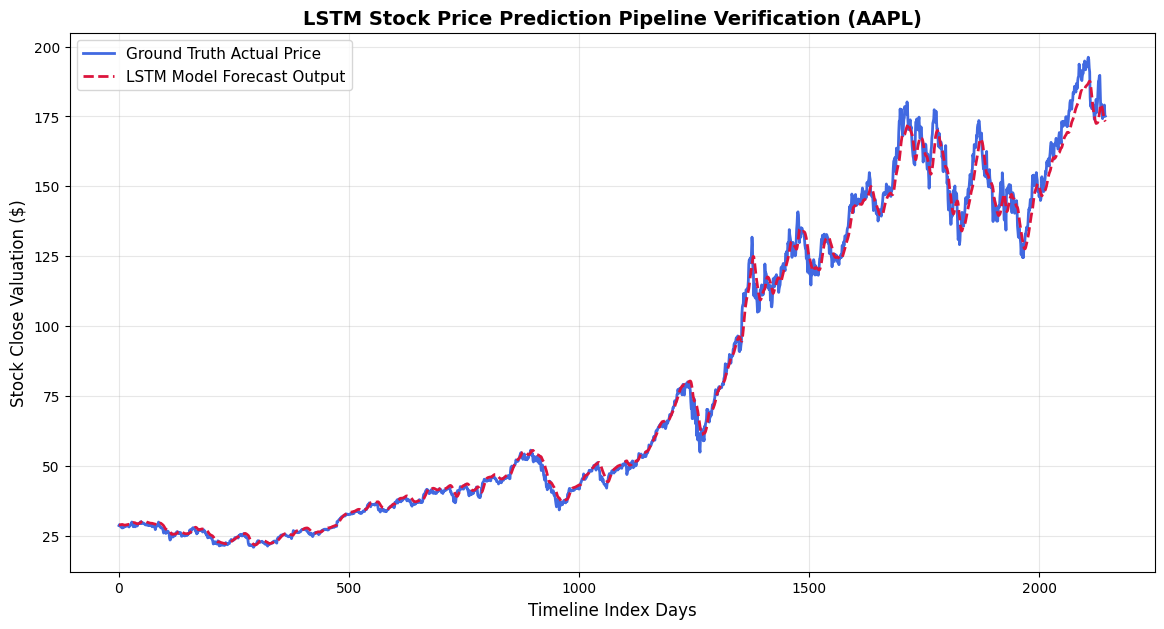

In [34]:
# Create a structured validation DataFrame for charting
train_df_len = train_size + prediction_days
valid_df = df.iloc[train_df_len:].copy().reset_index(drop=True)
valid_df['Predictions'] = predictions_decoded

# Plot Configuration
plt.figure(figsize=(14, 7))
plt.title(f"LSTM Stock Price Prediction Pipeline Verification ({target_stock.replace('.csv', '')})", fontsize=14, fontweight='bold')
plt.xlabel("Timeline Index Days", fontsize=12)
plt.ylabel("Stock Close Valuation ($)", fontsize=12)

# Plot actual vs predicted prices
plt.plot(valid_df['Close'], label='Ground Truth Actual Price', color='royalblue', linewidth=2)
plt.plot(valid_df['Predictions'], label='LSTM Model Forecast Output', color='crimson', linestyle='--', linewidth=2)

plt.grid(True, alpha=0.3)
plt.legend(loc='upper left', fontsize=11)
plt.show()

In [35]:
# 1. Isolate Apple data
aapl_file = os.path.join(path, "AAPL.csv")
df_aapl = pd.read_csv(aapl_file).dropna()
df_aapl['Date'] = pd.to_datetime(df_aapl['Date'])
df_aapl = df_aapl.sort_values('Date').reset_index(drop=True)

# 2. Extract and scale the target close values
aapl_target = df_aapl['Close'].values.reshape(-1, 1)
aapl_scaled = scaler.transform(aapl_target)

# 3. Extract the final 60-day sequence and reshape
aapl_last_60 = aapl_scaled[-prediction_days:]
aapl_aapl_X = np.reshape(aapl_last_60, (1, prediction_days, 1))

# 4. Predict and Inverse Scale
aapl_pred_scaled = model.predict(aapl_aapl_X)
aapl_pred = scaler.inverse_transform(aapl_pred_scaled)

# 5. Output results
print("\n================ APPLE (AAPL) FUTURE FORECAST ================")
print(f"Last recorded date in dataset: {df_aapl['Date'].max().strftime('%Y-%m-%d')}")
print(f"Last recorded closing price:  ${aapl_target[-1][0]:.2f}")
print(f"➡️ LSTM PREDICTED PRICE FOR THE NEXT TRADING DAY: ${aapl_pred[0][0]:.2f}")
print("==============================================================")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step

================ APPLE (AAPL) FUTURE FORECAST ================
Last recorded date in dataset: 2023-09-21
Last recorded closing price:  $175.12
➡️ LSTM PREDICTED PRICE FOR THE NEXT TRADING DAY: $172.81


/tmp/ipykernel_58/1335331058.py:4: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df_aapl['Date'] = pd.to_datetime(df_aapl['Date'])


In [36]:
model.save("lstm_model_aapl.keras")

In [37]:
# Select a prominent stock file from the dataset path (e.g., AAPL.csv)
# You can change 'AAPL.csv' to 'TSLA.csv' or any other ticker file available in the path.
target_stock = "TSLA.csv"
file_path = os.path.join(path, target_stock)

if not os.path.exists(file_path):
    # Fallback to the first available file if AAPL isn't named exactly
    file_path = csv_files[0]
    print(f"Target stock file not explicitly found. Falling back to: {os.path.basename(file_path)}")

# Load dataset
df = pd.read_csv(file_path)

# Data Preprocessing
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)
df = df.dropna()

print(f"Loaded {os.path.basename(file_path)} with shape: {df.shape}")
print(df.head())

# Filter out the Close price for univariate time-series tracking
data_target = df['Close'].values.reshape(-1, 1)

# Feature Scaling (Crucial for LSTM performance)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data_target)

Loaded TSLA.csv with shape: (3331, 8)
                        Date      Open      High       Low     Close  \
0  2010-06-29 00:00:00-04:00  1.266667  1.666667  1.169333  1.592667   
1  2010-06-30 00:00:00-04:00  1.719333  2.028000  1.553333  1.588667   
2  2010-07-01 00:00:00-04:00  1.666667  1.728000  1.351333  1.464000   
3  2010-07-02 00:00:00-04:00  1.533333  1.540000  1.247333  1.280000   
4  2010-07-06 00:00:00-04:00  1.333333  1.333333  1.055333  1.074000   

      Volume  Dividends  Stock Splits  
0  281494500        0.0           0.0  
1  257806500        0.0           0.0  
2  123282000        0.0           0.0  
3   77097000        0.0           0.0  
4  103003500        0.0           0.0  


/tmp/ipykernel_58/3647755138.py:15: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df['Date'] = pd.to_datetime(df['Date'])


In [38]:
# Lookback window (Using past 60 days of stock data to predict the 61st day)
prediction_days = 60

X = []
y = []

for i in range(prediction_days, len(scaled_data)):
    X.append(scaled_data[i - prediction_days:i, 0])
    y.append(scaled_data[i, 0])

X, y = np.array(X), np.array(y)

# Reshape X to fit the 3D tensor expected by LSTM: [samples, time_steps, features]
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

# Train-Test Split (Chronological split instead of random split to preserve time order)
train_size = int(len(X) * 0.80)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

Training features shape: (2616, 60, 1)
Testing features shape: (655, 60, 1)


In [39]:
# Initialize Sequential Model
model = Sequential()

# Layer 1: Stacked LSTM layer
model.add(LSTM(units=60, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))

# Layer 2: Second Stacked LSTM layer
model.add(LSTM(units=60, return_sequences=False))
model.add(Dropout(0.2))

# Layer 3: Dense output layer mapping to the next continuous price value
model.add(Dense(units=1))

# Compile using Adam Optimizer and Mean Squared Error Loss function
model.compile(optimizer='adam', loss='mean_squared_error')

# Configure Early Stopping to prevent overfitting if validation loss plateaus
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
print("Starting LSTM training pipeline...")
history = model.fit(
    X_train, y_train, 
    epochs=25, 
    batch_size=32, 
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

Starting LSTM training pipeline...
Epoch 1/25


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 9.3249e-04 - val_loss: 0.0092
Epoch 2/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.3420e-04 - val_loss: 0.0030
Epoch 3/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.6285e-04 - val_loss: 0.0039
Epoch 4/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.0564e-04 - val_loss: 0.0032
Epoch 5/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.7491e-04 - val_loss: 0.0027
Epoch 6/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.2695e-04 - val_loss: 0.0027
Epoch 7/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.4472e-04 - val_loss: 0.0036
Epoch 8/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.5320e-04 - val_loss: 0.0086
Epoch 9/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.3422e-04 - val_loss: 0.0026
Epoch 10/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.9014e-04 - val_loss: 0.0032
Epoch 11/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.4093e-04 - val_loss: 0.0020
Epoch 12/25
82/82 ━━━━━━━━━━━━

In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Execute Predictions
predictions = model.predict(X_test)

# Inverse scale back to authentic dollar currency valuations
predictions_decoded = scaler.inverse_transform(predictions)
y_test_decoded = scaler.inverse_transform(y_test.reshape(-1, 1))

# Calculate Evaluation Metrics
mae = mean_absolute_error(y_test_decoded, predictions_decoded)
mse = mean_squared_error(y_test_decoded, predictions_decoded)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_decoded, predictions_decoded)

print("\n=== Model Performance Evaluation ===")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score (Variance Explained): {r2:.4f}")

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

=== Model Performance Evaluation ===
Mean Absolute Error (MAE): 11.57
Mean Squared Error (MSE): 230.42
Root Mean Squared Error (RMSE): 15.18
R² Score (Variance Explained): 0.9334


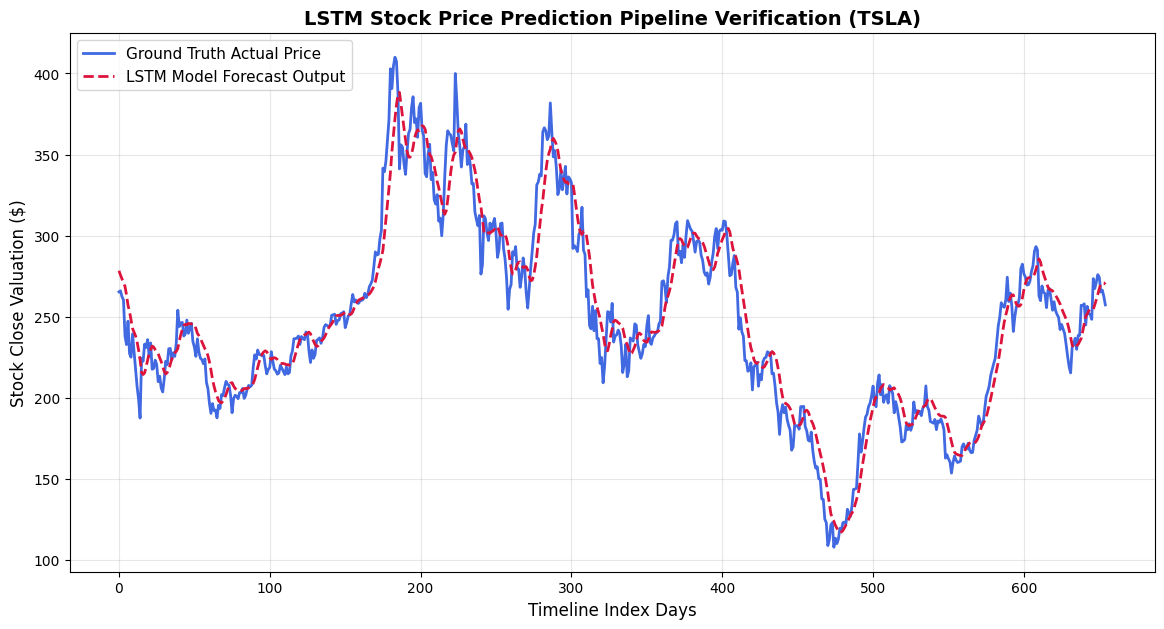

In [41]:
# Create a structured validation DataFrame for charting
train_df_len = train_size + prediction_days
valid_df = df.iloc[train_df_len:].copy().reset_index(drop=True)
valid_df['Predictions'] = predictions_decoded

# Plot Configuration
plt.figure(figsize=(14, 7))
plt.title(f"LSTM Stock Price Prediction Pipeline Verification ({target_stock.replace('.csv', '')})", fontsize=14, fontweight='bold')
plt.xlabel("Timeline Index Days", fontsize=12)
plt.ylabel("Stock Close Valuation ($)", fontsize=12)

# Plot actual vs predicted prices
plt.plot(valid_df['Close'], label='Ground Truth Actual Price', color='royalblue', linewidth=2)
plt.plot(valid_df['Predictions'], label='LSTM Model Forecast Output', color='crimson', linestyle='--', linewidth=2)

plt.grid(True, alpha=0.3)
plt.legend(loc='upper left', fontsize=11)
plt.show()

In [44]:
model.save("lstm_model_tsla.keras")

In [45]:
# 1. Isolate Tesla data
tsla_file = os.path.join(path, "TSLA.csv")
df_tsla = pd.read_csv(tsla_file).dropna()
df_tsla['Date'] = pd.to_datetime(df_tsla['Date'])
df_tsla = df_tsla.sort_values('Date').reset_index(drop=True)

# 2. Extract and scale the target close values
tsla_target = df_tsla['Close'].values.reshape(-1, 1)
tsla_scaled = scaler.transform(tsla_target)

# 3. Extract the final 60-day sequence and reshape
tsla_last_60 = tsla_scaled[-prediction_days:]
tsla_X = np.reshape(tsla_last_60, (1, prediction_days, 1))

# 4. Predict and Inverse Scale
tsla_pred_scaled = model.predict(tsla_X)
tsla_pred = scaler.inverse_transform(tsla_pred_scaled)

# 5. Output results
print("\n================ TESLA (TSLA) FUTURE FORECAST ================")
print(f"Last recorded date in dataset: {df_tsla['Date'].max().strftime('%Y-%m-%d')}")
print(f"Last recorded closing price:  ${tsla_target[-1][0]:.2f}")
print(f"➡️ LSTM PREDICTED PRICE FOR THE NEXT TRADING DAY: ${tsla_pred[0][0]:.2f}")
print("==============================================================")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step

================ TESLA (TSLA) FUTURE FORECAST ================
Last recorded date in dataset: 2023-09-21
Last recorded closing price:  $257.39
➡️ LSTM PREDICTED PRICE FOR THE NEXT TRADING DAY: $267.96


/tmp/ipykernel_58/4279323030.py:4: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df_tsla['Date'] = pd.to_datetime(df_tsla['Date'])


In [46]:
from tensorflow.keras.models import load_model

# ===============================================================
# 1. NVIDIA (NVDA) FUTURE FORECAST
# ===============================================================
if os.path.exists("lstm_model_nvda.keras"):
    nvda_model = load_model("lstm_model_nvda.keras")
    
    df_nvda = pd.read_csv(os.path.join(path, "NVDA.csv")).dropna()
    df_nvda['Date'] = pd.to_datetime(df_nvda['Date'])
    df_nvda = df_nvda.sort_values('Date').reset_index(drop=True)
    
    nvda_target = df_nvda['Close'].values.reshape(-1, 1)
    nvda_scaled = scaler.transform(nvda_target)
    nvda_last_60 = nvda_scaled[-prediction_days:]
    nvda_X = np.reshape(nvda_last_60, (1, prediction_days, 1))
    
    nvda_pred = scaler.inverse_transform(nvda_model.predict(nvda_X))
    
    print("\n================ NVIDIA (NVDA) FUTURE FORECAST ================")
    print(f"Last recorded closing price:  ${nvda_target[-1][0]:.2f}")
    print(f"➡️ LSTM PREDICTED PRICE FOR TOMORROW: ${nvda_pred[0][0]:.2f}")
else:
    print("\n[!] 'lstm_model_nvda.keras' not found. Please train and save the NVIDIA model first.")


# ===============================================================
# 2. APPLE (AAPL) FUTURE FORECAST
# ===============================================================
if os.path.exists("lstm_model_aapl.keras"):
    aapl_model = load_model("lstm_model_aapl.keras")
    
    df_aapl = pd.read_csv(os.path.join(path, "AAPL.csv")).dropna()
    df_aapl['Date'] = pd.to_datetime(df_aapl['Date'])
    df_aapl = df_aapl.sort_values('Date').reset_index(drop=True)
    
    aapl_target = df_aapl['Close'].values.reshape(-1, 1)
    aapl_scaled = scaler.transform(aapl_target)
    aapl_last_60 = aapl_scaled[-prediction_days:]
    aapl_X = np.reshape(aapl_last_60, (1, prediction_days, 1))
    
    aapl_pred = scaler.inverse_transform(aapl_model.predict(aapl_X))
    
    print("\n================ APPLE (AAPL) FUTURE FORECAST ================")
    print(f"Last recorded closing price:  ${aapl_target[-1][0]:.2f}")
    print(f"➡️ LSTM PREDICTED PRICE FOR TOMORROW: ${aapl_pred[0][0]:.2f}")
else:
    print("\n[!] 'lstm_model_aapl.keras' not found. Please train and save the Apple model first.")


# ===============================================================
# 3. TESLA (TSLA) FUTURE FORECAST
# ===============================================================
if os.path.exists("lstm_model_tsla.keras"):
    tsla_model = load_model("lstm_model_tsla.keras")
    
    df_tsla = pd.read_csv(os.path.join(path, "TSLA.csv")).dropna()
    df_tsla['Date'] = pd.to_datetime(df_tsla['Date'])
    df_tsla = df_tsla.sort_values('Date').reset_index(drop=True)
    
    tsla_target = df_tsla['Close'].values.reshape(-1, 1)
    tsla_scaled = scaler.transform(tsla_target)
    tsla_last_60 = tsla_scaled[-prediction_days:]
    tsla_X = np.reshape(tsla_last_60, (1, prediction_days, 1))
    
    tsla_pred = scaler.inverse_transform(tsla_model.predict(tsla_X))
    
    print("\n================ TESLA (TSLA) FUTURE FORECAST ================")
    print(f"Last recorded closing price:  ${tsla_target[-1][0]:.2f}")
    print(f"➡️ LSTM PREDICTED PRICE FOR TOMORROW: ${tsla_pred[0][0]:.2f}")
else:
    print("\n[!] 'lstm_model_tsla.keras' not found. Please train and save the Tesla model first.")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 10 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/tmp/ipykernel_58/547909639.py:10: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df_nvda['Date'] = pd.to_datetime(df_nvda['Date'])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step

================ NVIDIA (NVDA) FUTURE FORECAST ================
Last recorded closing price:  $414.38
➡️ LSTM PREDICTED PRICE FOR TOMORROW: $413.48


/tmp/ipykernel_58/547909639.py:34: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df_aapl['Date'] = pd.to_datetime(df_aapl['Date'])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step

================ APPLE (AAPL) FUTURE FORECAST ================
Last recorded closing price:  $175.12
➡️ LSTM PREDICTED PRICE FOR TOMORROW: $180.07


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 10 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/tmp/ipykernel_58/547909639.py:58: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df_tsla['Date'] = pd.to_datetime(df_tsla['Date'])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step

================ TESLA (TSLA) FUTURE FORECAST ================
Last recorded closing price:  $257.39
➡️ LSTM PREDICTED PRICE FOR TOMORROW: $267.96
